# 08 · Overfitting vs. Underfitting and Cross-Validation, Explained Visually

Companion notebook for the [lesson](https://github.com/younespuri/visual-machine-learning-for-beginners/blob/main/lessons/08-overfitting-and-cross-validation/README.md). Run the cells from top to bottom with **Shift + Enter**.

### Step 1 · Twenty days to learn from, twenty to test on

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split

def true_pattern(day):
    return 12 - 10 * np.cos(2 * np.pi * (day - 20) / 365)   # °C: coldest around January 20

rng = np.random.default_rng(897)
day = rng.uniform(0, 365, 40)                     # 40 random days of the year
temp = true_pattern(day) + rng.normal(0, 3, 40)   # plus day-to-day weather noise

day_train, day_test, temp_train, temp_test = train_test_split(
    day, temp, test_size=0.5, random_state=0)
print(len(day_train), "training days and", len(day_test), "test days")
print("the first 4 training days:", day_train[:4].round().astype(int))
print("their temperatures (°C):  ", temp_train[:4].round(1))
# 20 training days and 20 test days
# the first 4 training days: [106 207  39 293]
# their temperatures (°C):   [14.3 20.4  1.1 15.7]

20 training days and 20 test days
the first 4 training days: [106 207  39 293]
their temperatures (°C):   [14.3 20.4  1.1 15.7]


- `true_pattern` is the seasonal curve behind the data: coldest around January 20, warmest in late July. In real life nobody hands you the true pattern. We built this data ourselves, so we can peek.
- `rng.normal(0, 3, 40)` adds each day's random weather: noise with a standard deviation of 3 °C that no model can predict.
- `train_test_split` locks half of the days away as a test set. With only 40 days, a bigger test set keeps the test score from hanging on a handful of days.
- These are the exact 40 days in the picture at the top of this lesson.

### Step 2 · Too simple, just right, too complex

In [2]:
from sklearn.metrics import mean_squared_error

def report(name, predict):
    train_mse = mean_squared_error(temp_train, predict(day_train))
    test_mse = mean_squared_error(temp_test, predict(day_test))
    print(f"{name:<13} train MSE = {train_mse:4.1f}   test MSE = {test_mse:4.1f}")

for degree in [1, 4, 15]:
    curve = np.polynomial.Polynomial.fit(day_train, temp_train, deg=degree)
    report(f"degree {degree}", curve)
report("true pattern", true_pattern)
# degree 1      train MSE = 42.7   test MSE = 46.8
# degree 4      train MSE =  5.2   test MSE =  8.2
# degree 15     train MSE =  1.4   test MSE = 64.5
# true pattern  train MSE =  7.7   test MSE =  5.5

degree 1      train MSE = 42.7   test MSE = 46.8
degree 4      train MSE =  5.2   test MSE =  8.2
degree 15     train MSE =  1.4   test MSE = 64.5
true pattern  train MSE =  7.7   test MSE =  5.5


- `np.polynomial.Polynomial.fit(x, y, deg)` finds the curve of that degree with the lowest MSE on the training days. It's linear regression from lesson 02, with x, x², x³ and so on as the features. (scikit-learn can do the same with `PolynomialFeatures` plus `LinearRegression`.)
- The fitted curve works like a function: `curve(day_test)` predicts the test days. That's why `report` can grade the curves and the true pattern the same way.
- Degree 1 is bad on both sets: underfitting. Degree 15 has the lowest training error and by far the worst test error, a gap of 63: overfitting.
- Even the true pattern doesn't score 0, because nobody can predict the daily noise. Yet degree 15 scores 1.4 on the training days, *better than the truth itself* (7.7). The only way to do that is to memorize the noise.
- Degree 4 comes closest to the true pattern on both sets, so it's the one you want. Notice that we judged it with the test set, though. That's fine for a demo; from Step 4 on, you'll choose the honest way.

### See it

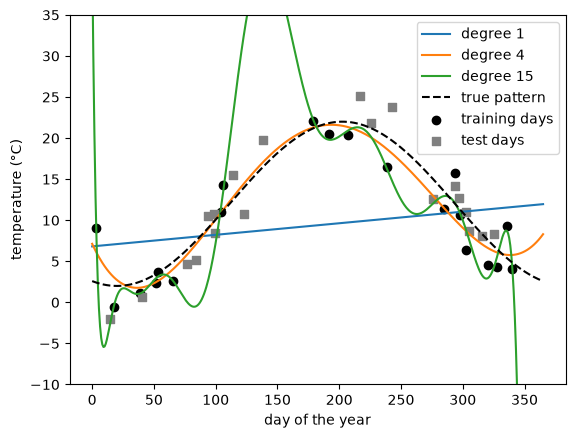

In [3]:
import matplotlib.pyplot as plt

xs = np.linspace(0, 365, 400)
for degree in [1, 4, 15]:
    curve = np.polynomial.Polynomial.fit(day_train, temp_train, deg=degree)
    plt.plot(xs, curve(xs), label=f"degree {degree}")
plt.plot(xs, true_pattern(xs), "k--", label="true pattern")
plt.scatter(day_train, temp_train, color="black", label="training days")
plt.scatter(day_test, temp_test, color="gray", marker="s", label="test days")
plt.ylim(-10, 35)
plt.xlabel("day of the year")
plt.ylabel("temperature (°C)")
plt.legend()
plt.show()

### Step 3 · The same story in a decision tree

In [4]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier

X, y = make_classification(n_samples=200, n_features=6, n_informative=4, n_redundant=1,
                           n_clusters_per_class=2, flip_y=0.08, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

for depth in [1, 4, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42).fit(X_train, y_train)
    print(f"max_depth={str(depth):<4}   train = {tree.score(X_train, y_train):.3f}   "
          f"test = {tree.score(X_test, y_test):.3f}   (grew {tree.get_depth()} deep)")
# max_depth=1      train = 0.673   test = 0.660   (grew 1 deep)
# max_depth=4      train = 0.893   test = 0.740   (grew 4 deep)
# max_depth=None   train = 1.000   test = 0.720   (grew 8 deep)

max_depth=1      train = 0.673   test = 0.660   (grew 1 deep)
max_depth=4      train = 0.893   test = 0.740   (grew 4 deep)
max_depth=None   train = 1.000   test = 0.720   (grew 8 deep)


- `make_classification` invents a classification dataset: 200 rows, 6 numeric features and 2 classes. `flip_y=0.08` flips about 8% of the labels at random. That's pure noise, like a few mislabeled records.
- With `max_depth=1`, the tree can ask only one question. Both scores are low and close together: underfitting.
- With no limit (`None`), the tree grows 8 questions deep and gets 100% of the training rows right, flipped labels included. On the test rows it drops to 72%. That 28-point gap is the signature of overfitting you met in lesson 04.
- `max_depth=4` gives up some training accuracy and does best on the test rows.
- From here on, the test set stays locked away until Step 8.

### Step 4 · One split can be lucky

In [5]:
val_scores = []
for seed in range(10):
    X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.25,
                                                  random_state=seed)
    tree = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_fit, y_fit)
    val_scores.append(tree.score(X_val, y_val))

print("validation accuracy:", np.round(val_scores, 2))
print(f"from {min(val_scores):.2f} to {max(val_scores):.2f}, for the very same model")
# validation accuracy: [0.68 0.82 0.89 0.76 0.71 0.68 0.66 0.76 0.76 0.87]
# from 0.66 to 0.89, for the very same model

validation accuracy: [0.68 0.82 0.89 0.76 0.71 0.68 0.66 0.76 0.76 0.87]
from 0.66 to 0.89, for the very same model


- Each round carves a different 38-row validation set out of the training data and grades the same depth-4 tree on it. The test set isn't touched.
- Same model, same data, and the grade swings from 66% to 89% depending only on which rows landed in the validation set. With a single split, you'd see just one of these numbers and never know whether it was a lucky one.
- `X_fit` is the part the tree trains on. The new name keeps it apart from `X_train`, which still holds all 150 training rows.

### Step 5 · k-fold cross-validation in one line

In [6]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
tree = DecisionTreeClassifier(max_depth=4, random_state=42)

scores = cross_val_score(tree, X_train, y_train, cv=kf)
print("fold scores:", scores.round(3))
print(f"mean = {scores.mean():.3f}   std = {scores.std():.3f}")
# fold scores: [0.8   0.733 0.867 0.733 0.867]
# mean = 0.800   std = 0.060

fold scores: [0.8   0.733 0.867 0.733 0.867]
mean = 0.800   std = 0.060


- `KFold(n_splits=5, shuffle=True, random_state=42)` shuffles the 150 training rows and deals them into 5 folds of 30. `random_state` makes the shuffle repeatable.
- `cross_val_score` runs the whole loop: 5 fresh trees, each trained on 4 folds and graded on the fifth. These are exactly the five scores in the k-fold picture above.
- The honest summary is *"about 80%, give or take 6 points"*: the mean and the standard deviation.
- It grades with the model's own `score` method, which is accuracy for classifiers and R² for regression models. Pass `scoring="recall"`, `scoring="r2"` or another metric name to grade by something else.

### Step 6 · Stratified folds keep the class mix

In [7]:
from sklearn.model_selection import StratifiedKFold

y_rare = np.array([1] * 10 + [0] * 90)     # 100 rows, only 10 of them in the rare class
X_rare = np.zeros((100, 1))                # the features don't matter for splitting

splitters = {"KFold": KFold(n_splits=5, shuffle=True, random_state=0),
             "StratifiedKFold": StratifiedKFold(n_splits=5, shuffle=True, random_state=0)}
for name, splitter in splitters.items():
    rare_per_fold = [int(y_rare[val].sum()) for _, val in splitter.split(X_rare, y_rare)]
    print(f"{name:<16} rare rows in each validation fold: {rare_per_fold}")
# KFold            rare rows in each validation fold: [3, 2, 4, 0, 1]
# StratifiedKFold  rare rows in each validation fold: [2, 2, 2, 2, 2]

KFold            rare rows in each validation fold: [3, 2, 4, 0, 1]
StratifiedKFold  rare rows in each validation fold: [2, 2, 2, 2, 2]


- `splitter.split(X, y)` hands out the row numbers of each round's training part and validation part. Here we just count the rare rows in each validation fold.
- Plain `KFold` left one fold with no rare rows at all and gave another 4. `StratifiedKFold` gives every fold the same 10%: exactly 2 each.
- For classifiers, `cv=5` means stratified folds automatically. Pass a `StratifiedKFold` yourself when you also want the rows shuffled with a fixed `random_state`, as you'll do in lesson 09.
- The classes in Step 3 are split almost exactly half and half (99 and 101 rows), so a plain split was fine there. With imbalanced classes, always stratify.

### Step 7 · Choose max_depth with cross-validation

In [8]:
for depth in [1, 2, 3, 4, 5, 6, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(tree, X_train, y_train, cv=5)
    print(f"max_depth={str(depth):<4}   CV accuracy = {scores.mean():.3f} ± {scores.std():.3f}")
# max_depth=1      CV accuracy = 0.600 ± 0.067
# max_depth=2      CV accuracy = 0.640 ± 0.053
# max_depth=3      CV accuracy = 0.733 ± 0.030
# max_depth=4      CV accuracy = 0.780 ± 0.069
# max_depth=5      CV accuracy = 0.740 ± 0.025
# max_depth=6      CV accuracy = 0.760 ± 0.033
# max_depth=None   CV accuracy = 0.740 ± 0.025

max_depth=1      CV accuracy = 0.600 ± 0.067
max_depth=2      CV accuracy = 0.640 ± 0.053
max_depth=3      CV accuracy = 0.733 ± 0.030
max_depth=4      CV accuracy = 0.780 ± 0.069
max_depth=5      CV accuracy = 0.740 ± 0.025
max_depth=6      CV accuracy = 0.760 ± 0.033
max_depth=None   CV accuracy = 0.740 ± 0.025


- Every depth gets its own 5-fold cross-validation on the training data. The test set stays locked away.
- The CV accuracy climbs, peaks at depth 4, then falls back: the U-curve from earlier, upside down, because this is accuracy instead of error.
- Depth 4 wins, but not by a landslide: depth 6 is only 0.02 behind, well inside the ± spread. When scores are this close, prefer the simpler model.
- Why 0.780 here but 0.800 in Step 5? `cv=5` builds different folds (stratified, and not shuffled). Both are estimates of the same thing, which is exactly why you report the ± too.

### Step 8 · Let GridSearchCV do the loop, then test once

In [9]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                    param_grid={"max_depth": [1, 2, 3, 4, 5, 6, None]}, cv=5)
grid.fit(X_train, y_train)                 # 7 settings x 5 folds = 35 trees, then 1 refit

print("best setting:    ", grid.best_params_)
print("best CV accuracy:", round(grid.best_score_, 3))
print("test accuracy:   ", round(grid.score(X_test, y_test), 3))   # the one and only look
# best setting:     {'max_depth': 4}
# best CV accuracy: 0.78
# test accuracy:    0.74

best setting:     {'max_depth': 4}
best CV accuracy: 0.78
test accuracy:    0.74


- `GridSearchCV` runs a full cross-validation for every value in `param_grid`, keeps the best, then refits that winner on all 150 training rows (`refit=True` is the default).
- `best_score_` comes from cross-validation on the training data, never from the test set. It matches the depth-4 row of Step 7.
- Only now do we look at the test set, once: 0.74. That's a little below the CV estimate, which is normal. It's the honest number you'd report.
- `param_grid` can hold several settings at once, like `{"max_depth": [3, 4, 5], "min_samples_leaf": [1, 5, 10]}`. `GridSearchCV` then tries every combination: 9 of them here.

### Step 9 · Keep the scaler inside the folds

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_wide = X_train * np.array([1, 100, 1, 1000, 1, 1])   # two features in much bigger units

models = {
    "KNN, raw features": KNeighborsClassifier(),
    "KNN, scaler in a pipeline": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "tree, raw features": DecisionTreeClassifier(max_depth=4, random_state=42),
}
for name, model in models.items():
    scores = cross_val_score(model, X_wide, y_train, cv=5)
    print(f"{name:<26} CV accuracy = {scores.mean():.3f}")
# KNN, raw features          CV accuracy = 0.493
# KNN, scaler in a pipeline  CV accuracy = 0.773
# tree, raw features         CV accuracy = 0.780

KNN, raw features          CV accuracy = 0.493
KNN, scaler in a pipeline  CV accuracy = 0.773
tree, raw features         CV accuracy = 0.780


- Multiplying two columns by 100 and 1,000 is like measuring them in centimeters instead of meters: the same information in bigger numbers. KNN measures distances, so those two columns take over, and accuracy falls to a coin flip (0.493).
- The pipeline brings it back up to 0.773. Inside `cross_val_score`, it refits the scaler in every fold, on that fold's training part only, so the validation fold never shapes the scaling.
- The tempting shortcut, `StandardScaler().fit_transform(X_wide)` before cross-validating, is leakage: the scaler would see every validation fold. For scaling the effect is often small, but leaky steps that learn more, such as choosing which features to keep, can make a useless model look excellent.
- The tree doesn't care about units and scores the same 0.780 as in Step 7. It asks about one feature at a time ("is this value above some threshold?"), so it needs no scaling. KNN, SVM and K-Means measure distances, so they do.